In [2]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import pandas as pd
import io
import glob

In [3]:
files = glob.glob("data/*.parquet")

dfs = [pd.read_parquet(file) for file in files]

df = pd.concat(dfs, ignore_index=True)

print("Final Dataset Shape: ", df.shape)

Final Dataset Shape:  (75750, 15)


In [4]:
df.head()

,image,label,id,clip_tags_ViT_L_14_with_openai_classes,clip_tags_ViT_L_14_wo_openai_classes,clip_tags_ViT_L_14_simple_specific,clip_tags_ViT_L_14_ensemble_specific,clip_tags_ViT_B_16_simple_specific,clip_tags_ViT_B_16_ensemble_specific,clip_tags_ViT_B_32_simple_specific,clip_tags_ViT_B_32_ensemble_specific,Attributes_ViT_L_14_descriptors_text_davinci_003_full,Attributes_LAION_ViT_H_14_2B_descriptors_text_davinci_003_full,clip_tags_LAION_ViT_H_14_2B_simple_specific,clip_tags_LAION_ViT_H_14_2B_ensemble_specific
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,6,0,"[deep fried mars bar, beignets, fried dough, f...","[beignets, fork, dessert, pancakes, bread pudd...",beignets,beignets,beignets,beignets,beignets,beignets,"[beignet which has square or round in shape, b...","[beignet which has square or round in shape, b...",beignets,beignets
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,6,1,"[beignets, sugar bowl, fried food, fried dough...","[beignets, beignet]",beignets,beignets,beignets,beignets,beignets,beignets,"[beignets which has served warm, beignets whic...","[beignets which has served warm, beignets whic...",beignets,beignets
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,6,2,"[beignets, sugar bowl, cajun food, mardi gras,...","[beignets, eater, beignet, mobile]",beignets,beignets,beignets,beignets,beignets,beignets,"[beignets which has round or square shape, bei...","[beignet which has golden-brown in color, beig...",beignets,beignets
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,6,3,"[crab cakes, brandade, falafel, fried clams, c...","[crab cakes, falafel, beignets, appetizer, eater]",crab cakes,crab cakes,crab cakes,crab cakes,falafel,falafel,[fritter which may be served with a dipping sa...,"[falafel which has small, round, deep-fried ba...",falafel,falafel
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,6,4,"[beignets, fried dough, zeppole, loukoumades, ...","[beignets, beignet, cruller, bolotie, fritter]",beignets,beignets,beignets,beignets,beignets,beignets,"[beignet which has square or round in shape, b...","[beignet which has golden-brown in color, beig...",beignets,beignets


In [5]:
print("Duplicates:", df.duplicated(subset=["id"]).sum())

Duplicates: 0


In [6]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
class FoodDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ----- Image Bytes → PIL -----
        image_bytes = row["image"]["bytes"]
        image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

        # ----- Transform -----
        if self.transform:
            image = self.transform(image)
        
        return image

In [8]:
dataset = FoodDataset(df, transform=transform)

In [9]:
dataset

In [10]:
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)

In [13]:
batch = next(iter(dataloader))

print(batch.shape)

torch.Size([4, 3, 224, 224])


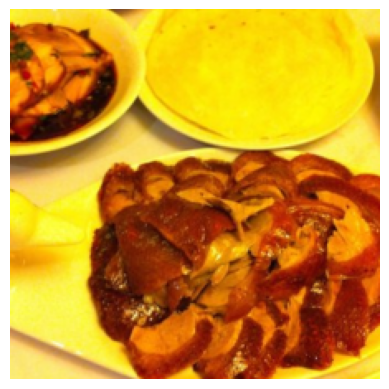

In [14]:
import matplotlib.pyplot as plt

img = batch[0].permute(1,2,0)

img = img * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406])
img = img.clamp(0,1)

plt.imshow(img)
plt.axis("off")
plt.show()